In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import pickle
import os

# Plotting style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('darkgrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('Car details v3.csv')

print(f'Shape : {df.shape[0]} rows × {df.shape[1]} columns')
print('='*60)
df.head()

Shape : 8128 rows × 13 columns


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
print('📋 Column Info & Data Types')
print('='*60)
df.info()

📋 Column Info & Data Types
<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [5]:
print('📊 Statistical Summary')
df.describe(include='all').T

📊 Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print('❓ Missing Values per Column')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

❓ Missing Values per Column
           Missing Count  Missing %
mileage              221       2.72
engine               221       2.72
max_power            215       2.65
torque               222       2.73
seats                221       2.72


In [7]:

# --- Raw value samples before cleaning ---
print('mileage sample :', df['mileage'].dropna().head(3).tolist())
print('engine  sample :', df['engine'].dropna().head(3).tolist())
print('max_power sample:', df['max_power'].dropna().head(3).tolist())
print('torque  sample :', df['torque'].dropna().head(3).tolist())


mileage sample : ['23.4 kmpl', '21.14 kmpl', '17.7 kmpl']
engine  sample : ['1248 CC', '1498 CC', '1497 CC']
max_power sample: ['74 bhp', '103.52 bhp', '78 bhp']
torque  sample : ['190Nm@ 2000rpm', '250Nm@ 1500-2500rpm', '12.7@ 2,700(kgm@ rpm)']


In [8]:
def extract_number(series):
    """Extract the leading float from a string column."""
    return pd.to_numeric(
        series.astype(str).str.extract(r'([\d\.]+)')[0],
        errors='coerce'
    )

df['mileage']   = extract_number(df['mileage'])
df['engine']    = extract_number(df['engine'])
df['max_power'] = extract_number(df['max_power'])

# torque: extract Nm value
df['torque_nm'] = pd.to_numeric(
    df['torque'].astype(str).str.extract(r'([\d\.]+)')[0],
    errors='coerce'
)
df.drop(columns=['torque'], inplace=True)

print('✅ Numeric extraction done')
df[['mileage','engine','max_power','torque_nm']].head()

✅ Numeric extraction done


,mileage,engine,max_power,torque_nm
0,23.40,1248.0,74.00,190.0
1,21.14,1498.0,103.52,250.0
2,17.70,1497.0,78.00,12.7
3,23.00,1396.0,90.00,22.4
4,16.10,1298.0,88.20,11.5


In [9]:
# Car age from year
df['car_age'] = 2024 - df['year']

# Extract brand from name
df['brand'] = df['name'].str.split().str[0].str.strip()

# Log-transform target (reduces right skew)
df['log_price'] = np.log1p(df['selling_price'])

print('✅ Feature engineering done')
print(f'   New features: car_age, brand, log_price')
print(f'   Unique brands: {df["brand"].nunique()}')

✅ Feature engineering done
   New features: car_age, brand, log_price
   Unique brands: 32


In [10]:
# Numeric: fill with median per fuel type
numeric_cols = ['mileage', 'engine', 'max_power', 'torque_nm', 'seats']

for col in numeric_cols:
    median_by_fuel = df.groupby('fuel')[col].transform('median')
    df[col] = df[col].fillna(median_by_fuel)
    # fallback global median
    df[col] = df[col].fillna(df[col].median())

print('✅ Missing values handled')
print('Remaining nulls:', df.isnull().sum()[df.isnull().sum() > 0])

✅ Missing values handled
Remaining nulls: Series([], dtype: int64)


In [11]:
# Verify no nulls remain in key columns
assert df[numeric_cols].isnull().sum().sum() == 0, 'Still has nulls!'
print('✅ No null values remain in numeric columns')

✅ No null values remain in numeric columns


In [12]:
# Keep top 20 brands; group rest as 'Other'
top_brands = df['brand'].value_counts().nlargest(20).index
df['brand'] = df['brand'].where(df['brand'].isin(top_brands), other='Other')

# One-hot encoding for low-cardinality categoricals
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print(f'Shape after encoding: {df_encoded.shape}')
print(f'Columns: {list(df_encoded.columns)}')

Shape after encoding: (8128, 46)
Columns: ['name', 'year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'torque_nm', 'car_age', 'log_price', 'fuel_CNG', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Automatic', 'transmission_Manual', 'owner_First Owner', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner', 'brand_Audi', 'brand_BMW', 'brand_Chevrolet', 'brand_Datsun', 'brand_Fiat', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Jaguar', 'brand_Lexus', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz', 'brand_Nissan', 'brand_Other', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo']


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        8128 non-null   float64
 9   engine         8128 non-null   float64
 10  max_power      8128 non-null   float64
 11  seats          8128 non-null   float64
 12  torque_nm      8128 non-null   float64
 13  car_age        8128 non-null   int64  
 14  brand          8128 non-null   object 
 15  log_price      8128 non-null   float64
dtypes: float64(6), int64(4), object(1), str(5)
memory usage: 1016.1+ KB


In [14]:
# Drop leaky / identifier columns
drop_cols = ['name', 'year', 'selling_price', 'log_price']
X = df_encoded.drop(columns=drop_cols, errors='ignore')
y = df['selling_price']  # actual price (in ₹)

# Ensure all columns are numeric
X = X.select_dtypes(include=[np.number])

print(f'Feature matrix X : {X.shape}')
print(f'Target y         : {y.shape}')
print(f'Features used    : {list(X.columns)}')

Feature matrix X : (8128, 7)
Target y         : (8128,)
Features used    : ['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'torque_nm', 'car_age']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train set : {X_train.shape[0]} samples')
print(f'Test set  : {X_test.shape[0]} samples')
print('✅ Scaling complete')

Train set : 6502 samples
Test set  : 1626 samples
✅ Scaling complete


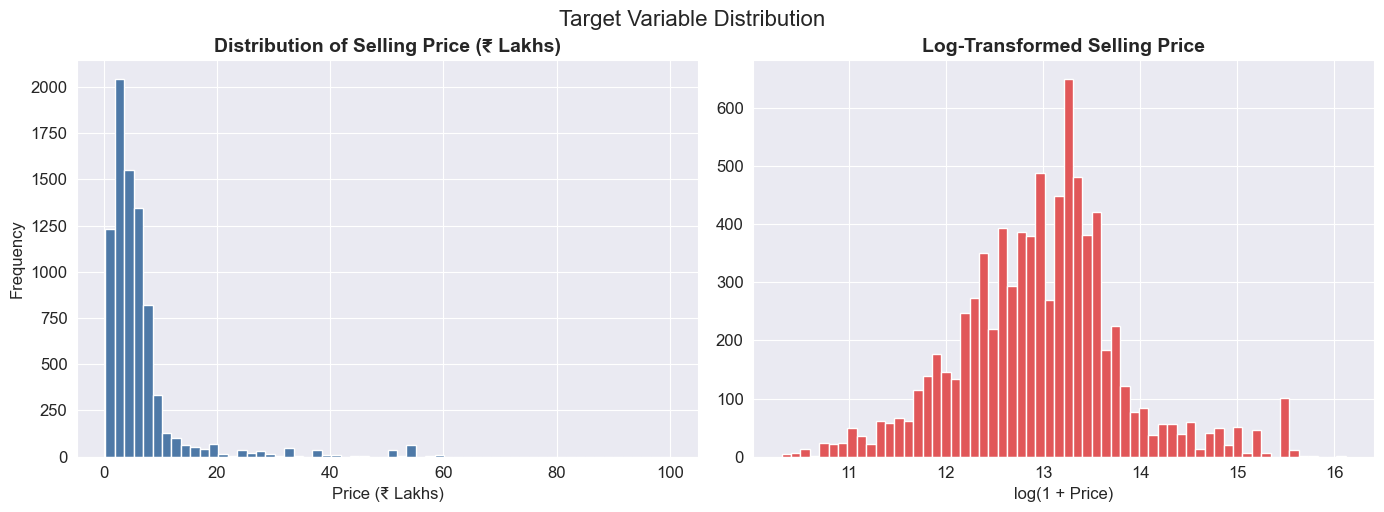

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of selling price
axes[0].hist(df['selling_price'] / 1e5, bins=60, color='#4e79a7', edgecolor='white')
axes[0].set_title('Distribution of Selling Price (₹ Lakhs)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (₹ Lakhs)')
axes[0].set_ylabel('Frequency')

# Log-transformed
axes[1].hist(np.log1p(df['selling_price']), bins=60, color='#e15759', edgecolor='white')
axes[1].set_title('Log-Transformed Selling Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.suptitle('Target Variable Distribution', fontsize=16, y=1.02)
plt.show()

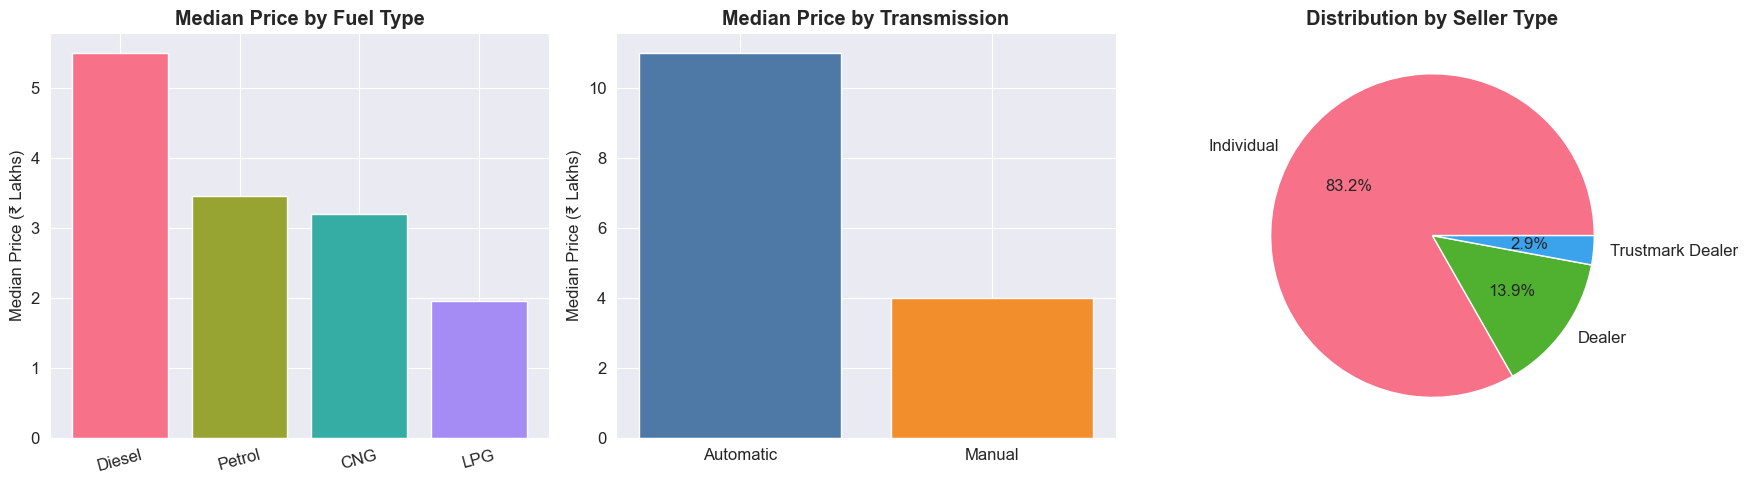

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Avg price by fuel
fuel_avg = df.groupby('fuel')['selling_price'].median().sort_values(ascending=False) / 1e5
axes[0].bar(fuel_avg.index, fuel_avg.values, color=sns.color_palette('husl', len(fuel_avg)))
axes[0].set_title('Median Price by Fuel Type', fontweight='bold')
axes[0].set_ylabel('Median Price (₹ Lakhs)')
axes[0].tick_params(axis='x', rotation=15)

# Avg price by transmission
trans_avg = df.groupby('transmission')['selling_price'].median().sort_values(ascending=False) / 1e5
axes[1].bar(trans_avg.index, trans_avg.values, color=['#4e79a7','#f28e2b'])
axes[1].set_title('Median Price by Transmission', fontweight='bold')
axes[1].set_ylabel('Median Price (₹ Lakhs)')

# Count by seller type
seller_counts = df['seller_type'].value_counts()
axes[2].pie(seller_counts.values, labels=seller_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('husl', len(seller_counts)))
axes[2].set_title('Distribution by Seller Type', fontweight='bold')

plt.tight_layout()
plt.show()

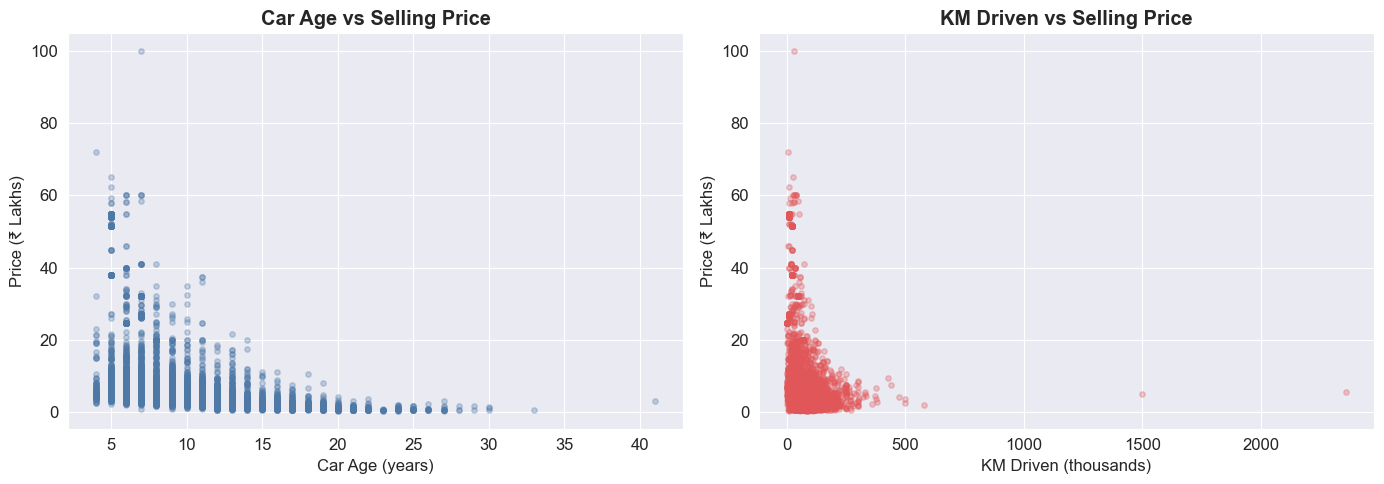

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Car age vs price
axes[0].scatter(df['car_age'], df['selling_price']/1e5,
                alpha=0.3, s=15, c='#4e79a7')
axes[0].set_title('Car Age vs Selling Price', fontweight='bold')
axes[0].set_xlabel('Car Age (years)')
axes[0].set_ylabel('Price (₹ Lakhs)')

# km_driven vs price
axes[1].scatter(df['km_driven']/1000, df['selling_price']/1e5,
                alpha=0.3, s=15, c='#e15759')
axes[1].set_title('KM Driven vs Selling Price', fontweight='bold')
axes[1].set_xlabel('KM Driven (thousands)')
axes[1].set_ylabel('Price (₹ Lakhs)')

plt.tight_layout()
plt.show()

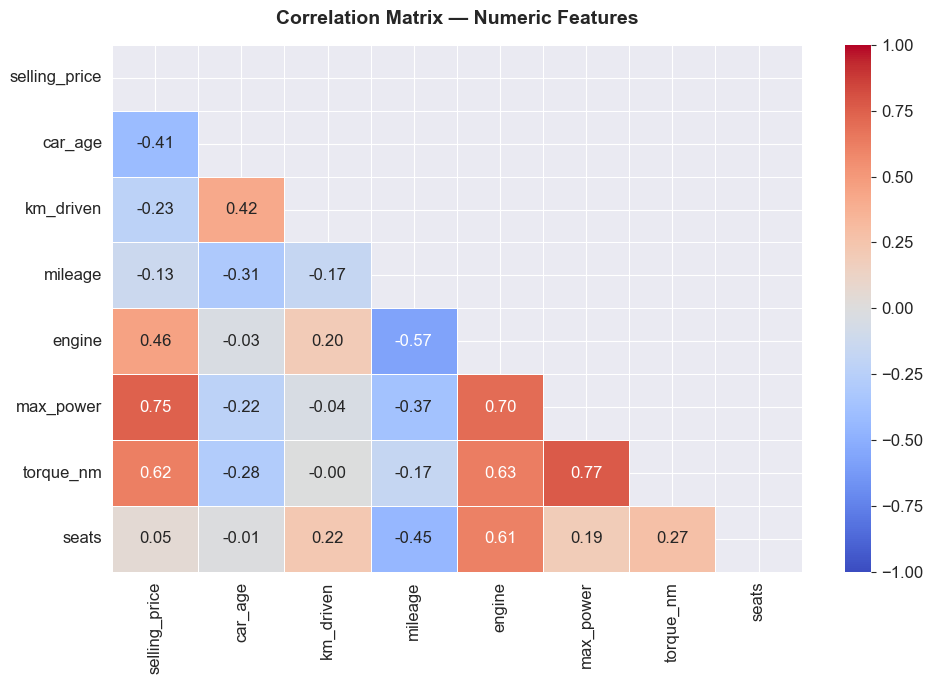

In [19]:
# Correlation heatmap (numeric features only)
num_features = ['selling_price', 'car_age', 'km_driven', 'mileage',
                'engine', 'max_power', 'torque_nm', 'seats']
corr = df[num_features].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

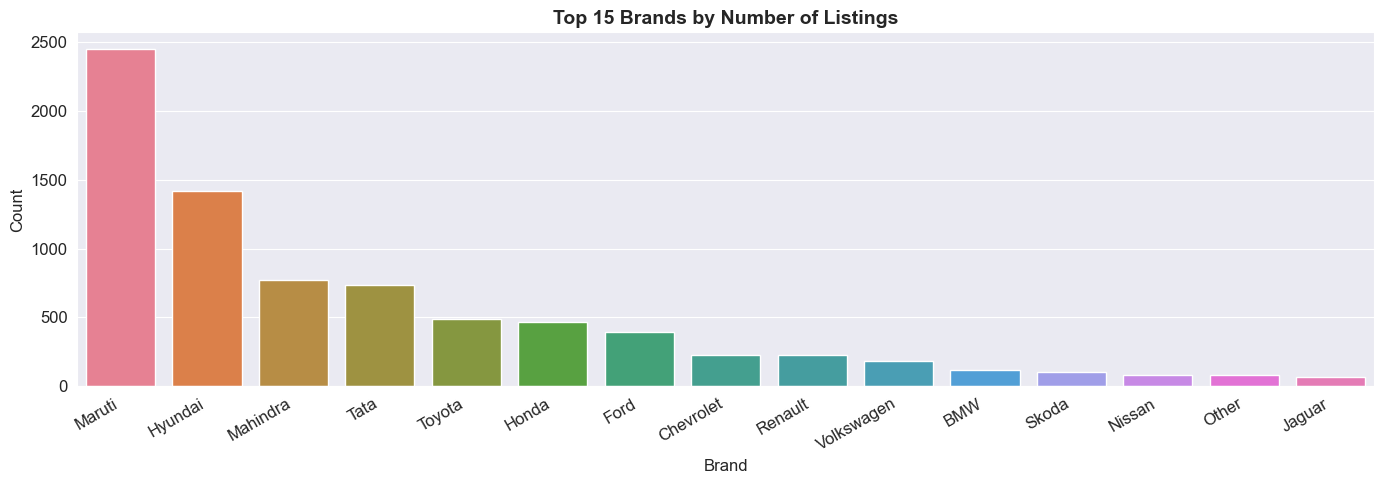

In [20]:
# Top 15 brands by car count
plt.figure(figsize=(14, 5))
brand_counts = df['brand'].value_counts().nlargest(15)
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette='husl')
plt.title('Top 15 Brands by Number of Listings', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

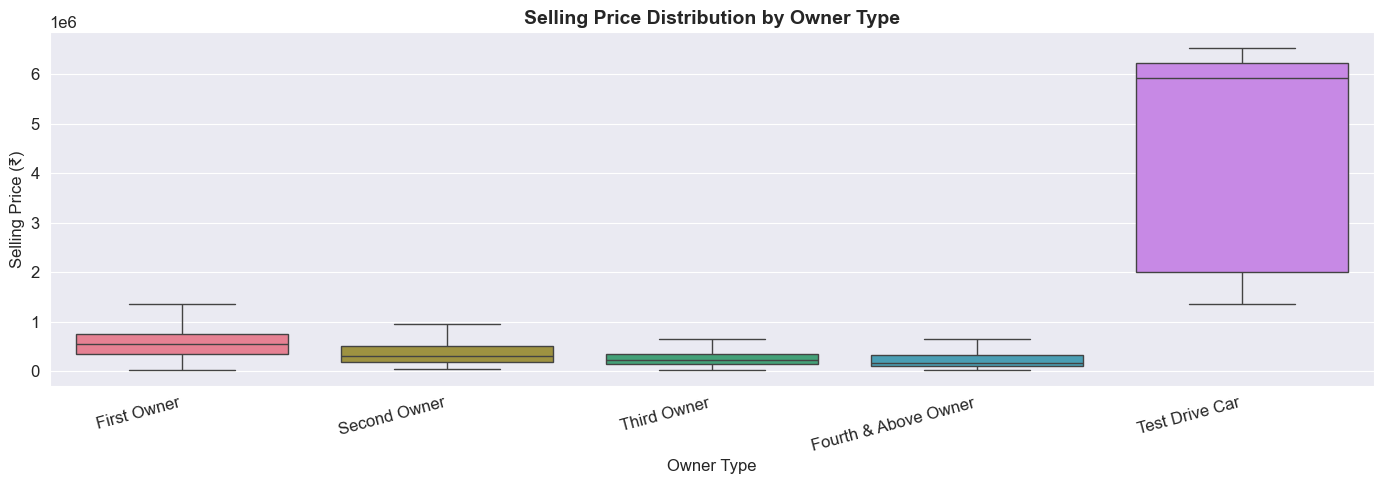

In [21]:
# Box plot: price distribution by owner type
plt.figure(figsize=(14, 5))
owner_order = ['First Owner','Second Owner','Third Owner','Fourth & Above Owner','Test Drive Car']
sns.boxplot(data=df, x='owner', y='selling_price', order=owner_order,
            palette='husl', showfliers=False)
plt.title('Selling Price Distribution by Owner Type', fontsize=14, fontweight='bold')
plt.xlabel('Owner Type')
plt.ylabel('Selling Price (₹)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [22]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    """Fit, predict and return metrics dict."""
    Xtr = X_tr if not scaled else X_train_sc
    Xte = X_te if not scaled else X_test_sc
    model.fit(Xtr, y_tr)
    preds = model.predict(Xte)
    # Clip negatives (price can't be < 0)
    preds = np.clip(preds, 0, None)
    mae  = mean_absolute_error(y_te, preds)
    mse  = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, preds)
    print(f'  {name:<30} MAE: ₹{mae:>10,.0f}  RMSE: ₹{rmse:>10,.0f}  R²: {r2:.4f}')
    return {'model': model, 'name': name, 'MAE': mae, 'MSE': mse,
            'RMSE': rmse, 'R2': r2, 'preds': preds, 'scaled': scaled}

print('Training models...')
print('='*75)
results = []

# Model 1: Linear Regression (Ridge)
ridge = Ridge(alpha=10)
results.append(evaluate_model('Ridge Regression', ridge,
                               X_train, X_test, y_train, y_test, scaled=True))

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
results.append(evaluate_model('Random Forest', rf,
                               X_train, X_test, y_train, y_test, scaled=False))

# Model 3: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.08,
                                max_depth=5, subsample=0.8, random_state=42)
results.append(evaluate_model('Gradient Boosting', gb,
                               X_train, X_test, y_train, y_test, scaled=False))

print('='*75)

Training models...
  Ridge Regression               MAE: ₹   251,697  RMSE: ₹   461,895  R²: 0.6745
  Random Forest                  MAE: ₹    73,305  RMSE: ₹   150,414  R²: 0.9655
  Gradient Boosting              MAE: ₹    71,773  RMSE: ₹   154,495  R²: 0.9636


In [23]:
metrics_df = pd.DataFrame([
    {'Model': r['name'], 'MAE (₹)': r['MAE'], 'RMSE (₹)': r['RMSE'], 'R² Score': r['R2']}
    for r in results
])
print(metrics_df.to_string(index=False))

            Model       MAE (₹)      RMSE (₹)  R² Score
 Ridge Regression 251697.141274 461894.614536  0.674521
    Random Forest  73304.815722 150413.887175  0.965485
Gradient Boosting  71772.571465 154494.773847  0.963586


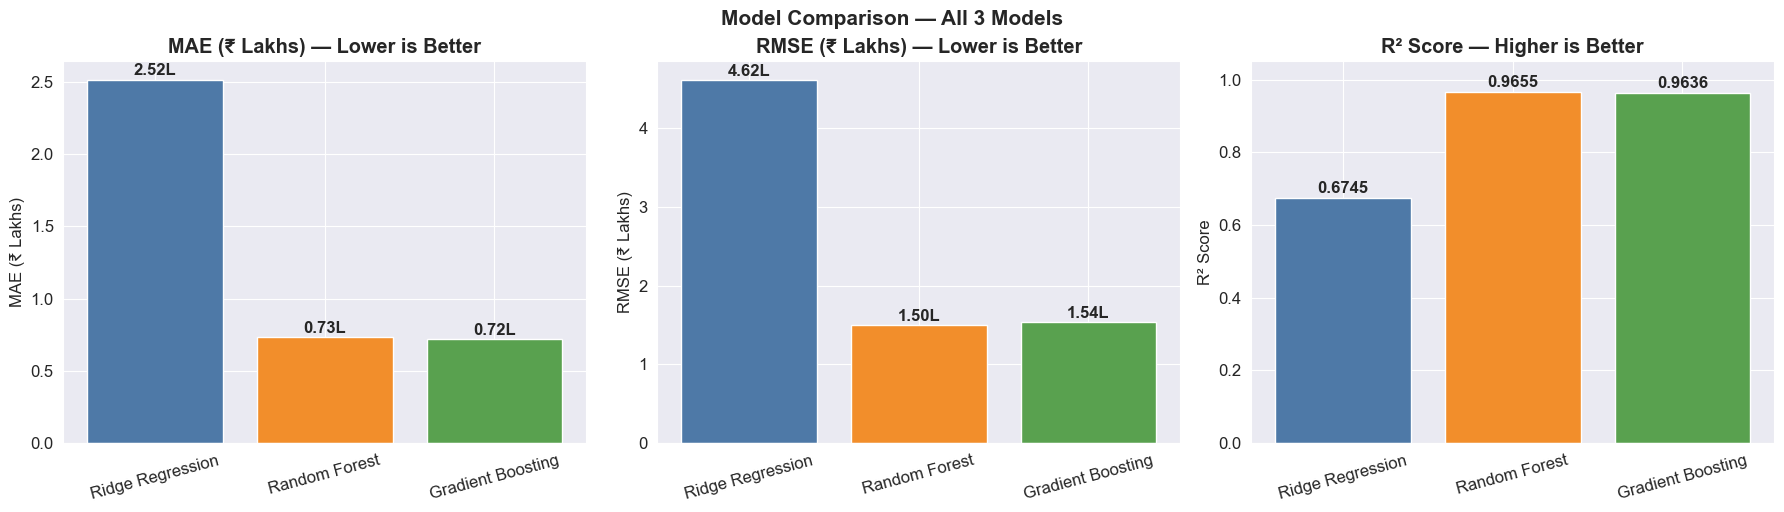

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['name'] for r in results]
colors = ['#4e79a7', '#f28e2b', '#59a14f']

# MAE
maes = [r['MAE']/1e5 for r in results]
bars = axes[0].bar(model_names, maes, color=colors)
axes[0].set_title('MAE (₹ Lakhs) — Lower is Better', fontweight='bold')
axes[0].set_ylabel('MAE (₹ Lakhs)')
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}L', ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# RMSE
rmses = [r['RMSE']/1e5 for r in results]
bars2 = axes[1].bar(model_names, rmses, color=colors)
axes[1].set_title('RMSE (₹ Lakhs) — Lower is Better', fontweight='bold')
axes[1].set_ylabel('RMSE (₹ Lakhs)')
for bar, val in zip(bars2, rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}L', ha='center', va='bottom', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# R²
r2s = [r['R2'] for r in results]
bars3 = axes[2].bar(model_names, r2s, color=colors)
axes[2].set_title('R² Score — Higher is Better', fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1.05)
for bar, val in zip(bars3, r2s):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.suptitle('Model Comparison — All 3 Models', fontsize=15, fontweight='bold', y=1.02)
plt.show()

In [25]:
# Select best model by R² score
best_result = max(results, key=lambda r: r['R2'])
best_model  = best_result['model']
best_name   = best_result['name']
best_preds  = best_result['preds']

print(f'🏆 Best Model  : {best_name}')
print(f'   MAE         : ₹{best_result["MAE"]:>10,.0f}')
print(f'   MSE         : ₹{best_result["MSE"]:>10,.0f}')
print(f'   RMSE        : ₹{best_result["RMSE"]:>10,.0f}')
print(f'   R² Score    : {best_result["R2"]:.6f}')

🏆 Best Model  : Random Forest
   MAE         : ₹    73,305
   MSE         : ₹22,624,337,455
   RMSE        : ₹   150,414
   R² Score    : 0.965485


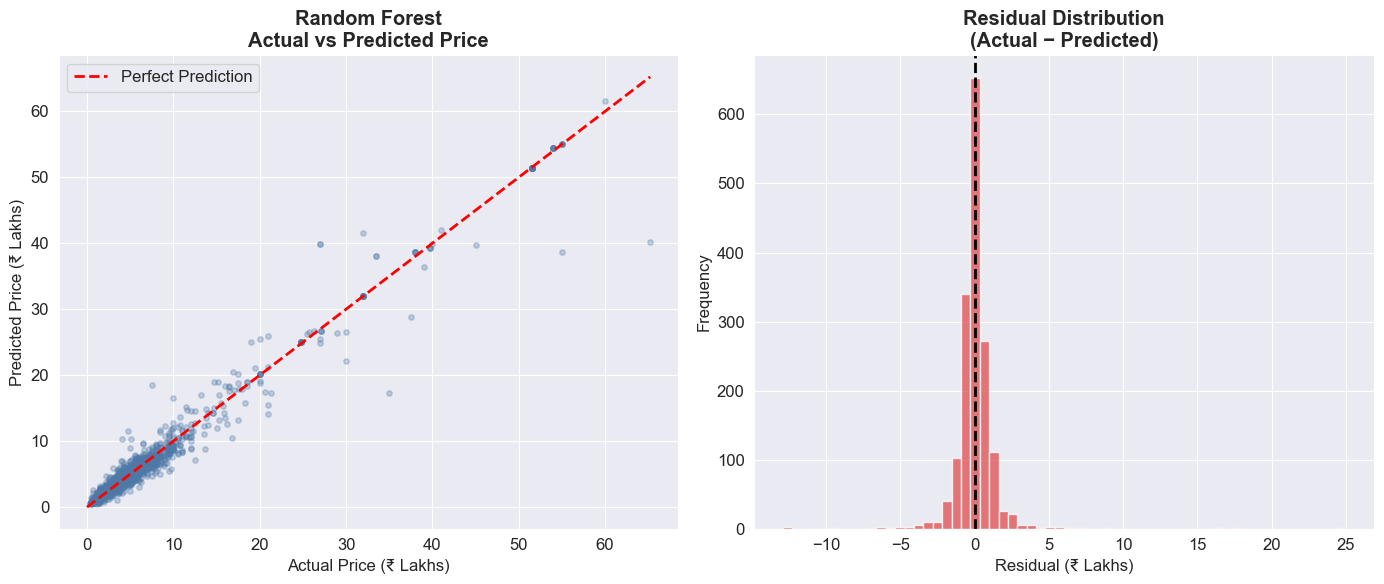

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_test/1e5, best_preds/1e5, alpha=0.3, s=15, c='#4e79a7')
lim = max(y_test.max(), best_preds.max()) / 1e5
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'{best_name}\nActual vs Predicted Price', fontweight='bold')
axes[0].set_xlabel('Actual Price (₹ Lakhs)')
axes[0].set_ylabel('Predicted Price (₹ Lakhs)')
axes[0].legend()

# Residuals
residuals = (y_test - best_preds) / 1e5
axes[1].hist(residuals, bins=60, color='#e15759', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', lw=2, linestyle='--')
axes[1].set_title('Residual Distribution\n(Actual − Predicted)', fontweight='bold')
axes[1].set_xlabel('Residual (₹ Lakhs)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

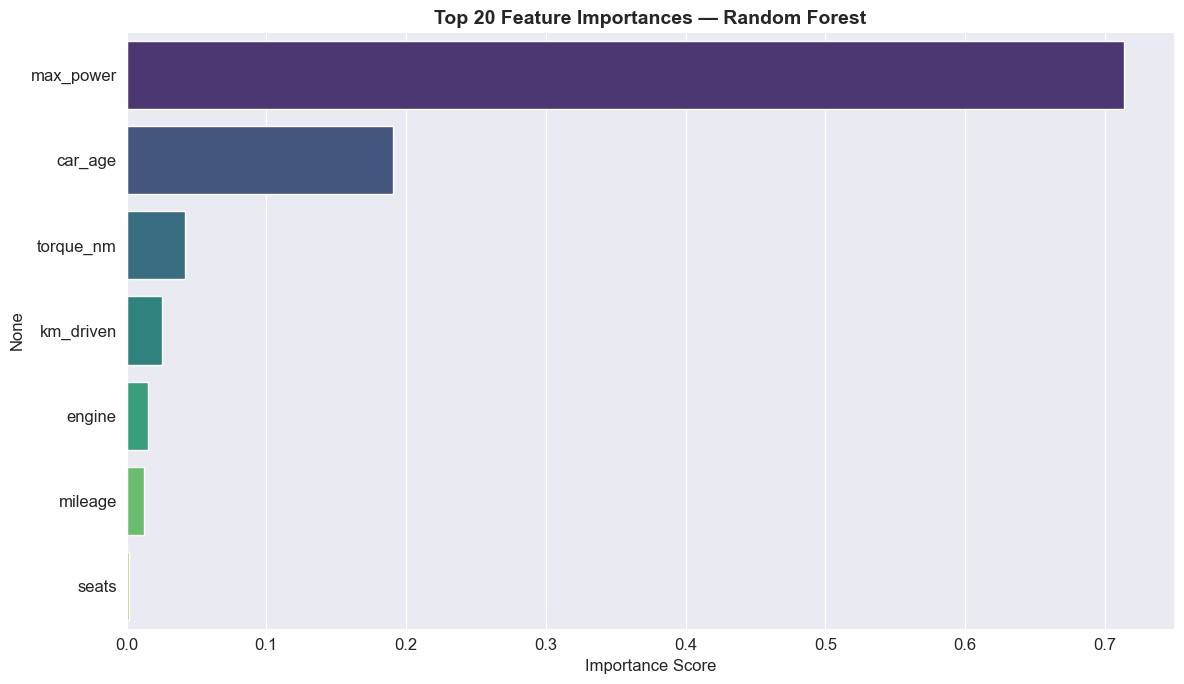

In [27]:
# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).nlargest(20)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
    plt.title(f'Top 20 Feature Importances — {best_name}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance not available for this model.')

In [28]:
# Cross-validation on training set
print(f'Running 5-Fold Cross Validation on {best_name}...')
Xtr_cv = X_train_sc if best_result['scaled'] else X_train
cv_scores = cross_val_score(best_model, Xtr_cv, y_train,
                             cv=5, scoring='r2', n_jobs=-1)
print(f'CV R² Scores : {cv_scores.round(4)}')
print(f'Mean R²      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Running 5-Fold Cross Validation on Random Forest...
CV R² Scores : [0.9407 0.9667 0.9668 0.9677 0.9608]
Mean R²      : 0.9606 ± 0.0102


In [29]:
# Save objects needed for the frontend
import pickle

artifacts = {
    'model'       : best_model,
    'scaler'      : scaler,
    'feature_cols': list(X.columns),
    'model_name'  : best_name,
    'top_brands'  : list(top_brands) + ['Other'],
}

with open('car_price_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('✅ Model artifacts saved to car_price_model.pkl')

✅ Model artifacts saved to car_price_model.pkl
